<a href="https://colab.research.google.com/github/ssanrey/Mushroom-Classification/blob/main/cpsc483project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Framing the problem

# Getting the data

In [ ]:
# install the UCI ML repository

!pip install ucimlrepo

In [ ]:
# retrieve the UCI mushroom dataset and separate the data into features and targets

from ucimlrepo import fetch_ucirepo
mushroom = fetch_ucirepo(id=73)

x = mushroom.data.features
y = mushroom.data.targets

display(x)
display(y.value_counts())

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,...,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,...,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l


,count
poisonous,
e,4208
p,3916


# Exploratory data analysis

## Identifying which features are the strongest indicators of edibility

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
# creating dataframe and taking our first look at the data

df = x.copy()
df['class'] = y.values.ravel() # ravel to convert a 2D array into 1D

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['class'].value_counts())
print("\nUnique values per feature:")
print(df.nunique().sort_values())


Shape: (8124, 23)

Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Unique values per feature:
veil-type                    1
bruises                      2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
gill-attachment              2
class                        2
ring-number                  3
stalk-surface-below-ring     4
stalk-root                   4
cap-surface                  4
stalk-surface-above-ring     4
veil-color                   4
ring-type                    5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64


We can see from taking a look at the number of unique values each feature has that "veil-type" only has one, meaning we can easily exclude it from the set of features we'll be training the model on.

In [ ]:
# check how many edible and poisonous

print(df['class'].value_counts())

class
e    4208
p    3916
Name: count, dtype: int64


This looks like a pretty good dataset to train with, since we've got an almost even number of samples for each classification category.

In [ ]:
# check for missing values
null_counts = x.isnull().sum()
null_percentages = (null_counts / len(x)) * 100
total_nulls = null_counts.sum()

null_summary = pd.DataFrame({
    'Total NA': null_counts,
    'Percentage': null_percentages.round(2)
})
print(null_summary)
print(f"Total NA values in dataset: {total_nulls}")

                          Total NA  Percentage
cap-shape                        0        0.00
cap-surface                      0        0.00
cap-color                        0        0.00
bruises                          0        0.00
odor                             0        0.00
gill-attachment                  0        0.00
gill-spacing                     0        0.00
gill-size                        0        0.00
gill-color                       0        0.00
stalk-shape                      0        0.00
stalk-root                    2480       30.53
stalk-surface-above-ring         0        0.00
stalk-surface-below-ring         0        0.00
stalk-color-above-ring           0        0.00
stalk-color-below-ring           0        0.00
veil-type                        0        0.00
veil-color                       0        0.00
ring-number                      0        0.00
ring-type                        0        0.00
spore-print-color                0        0.00
population   

By checking the dataset for null values, we were able to identify that the feature "stalk-root" is missing ~30% of its entries.

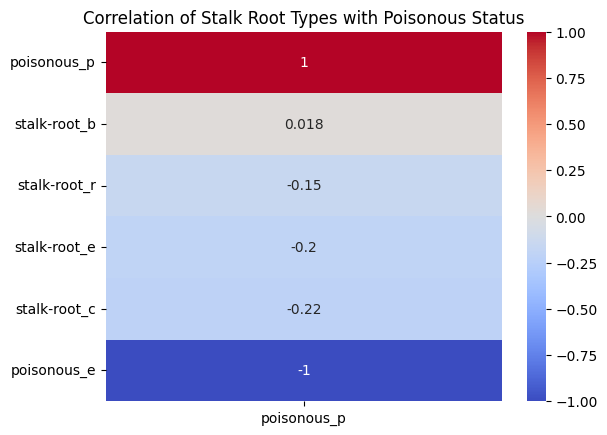

class          e     p
stalk-root            
b           1920  1856
c            512    44
e            864   256
missing      720  1760
r            192     0


/tmp/ipykernel_51735/876749794.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['stalk-root'] = x['stalk-root'].fillna('unknown')


In [ ]:
# Correlation matrix
corr_df=pd.concat([y,
                   x['stalk-root']],
                   axis = 1
                  )

corr_matrix_data = pd.get_dummies(corr_df)

corr_matrix = corr_matrix_data.corr()

sns.heatmap(corr_matrix[['poisonous_p']].sort_values(by = 'poisonous_p', ascending = False),
            annot = True,
            cmap='coolwarm'
            )
plt.title('Correlation of Stalk Root Types with Poisonous Status')
plt.show()

# Crosstab analysis
print(pd.crosstab(df['stalk-root'].fillna('missing'),
                  df['class'])
)

# Missing values as 'unknown'
x['stalk-root'] = x['stalk-root'].fillna('unknown')

Since our objective is to identify a mushrooms toxicity based on physical characteristics, we utilized a correlation matrix to evaluate the "stalk-root" feature before discarding it. While the matrix shows a weak relationship between a mushroom's toxicity and the stalk root type, the crosstab analysis shows that the feature is significant in terms of identification. Specifically, we see that the "r" category is an indicator of edibility and the "missing" category is heavily skewed towards poisonous samples. Thus, we choose to treat the missing values as a distinct category.

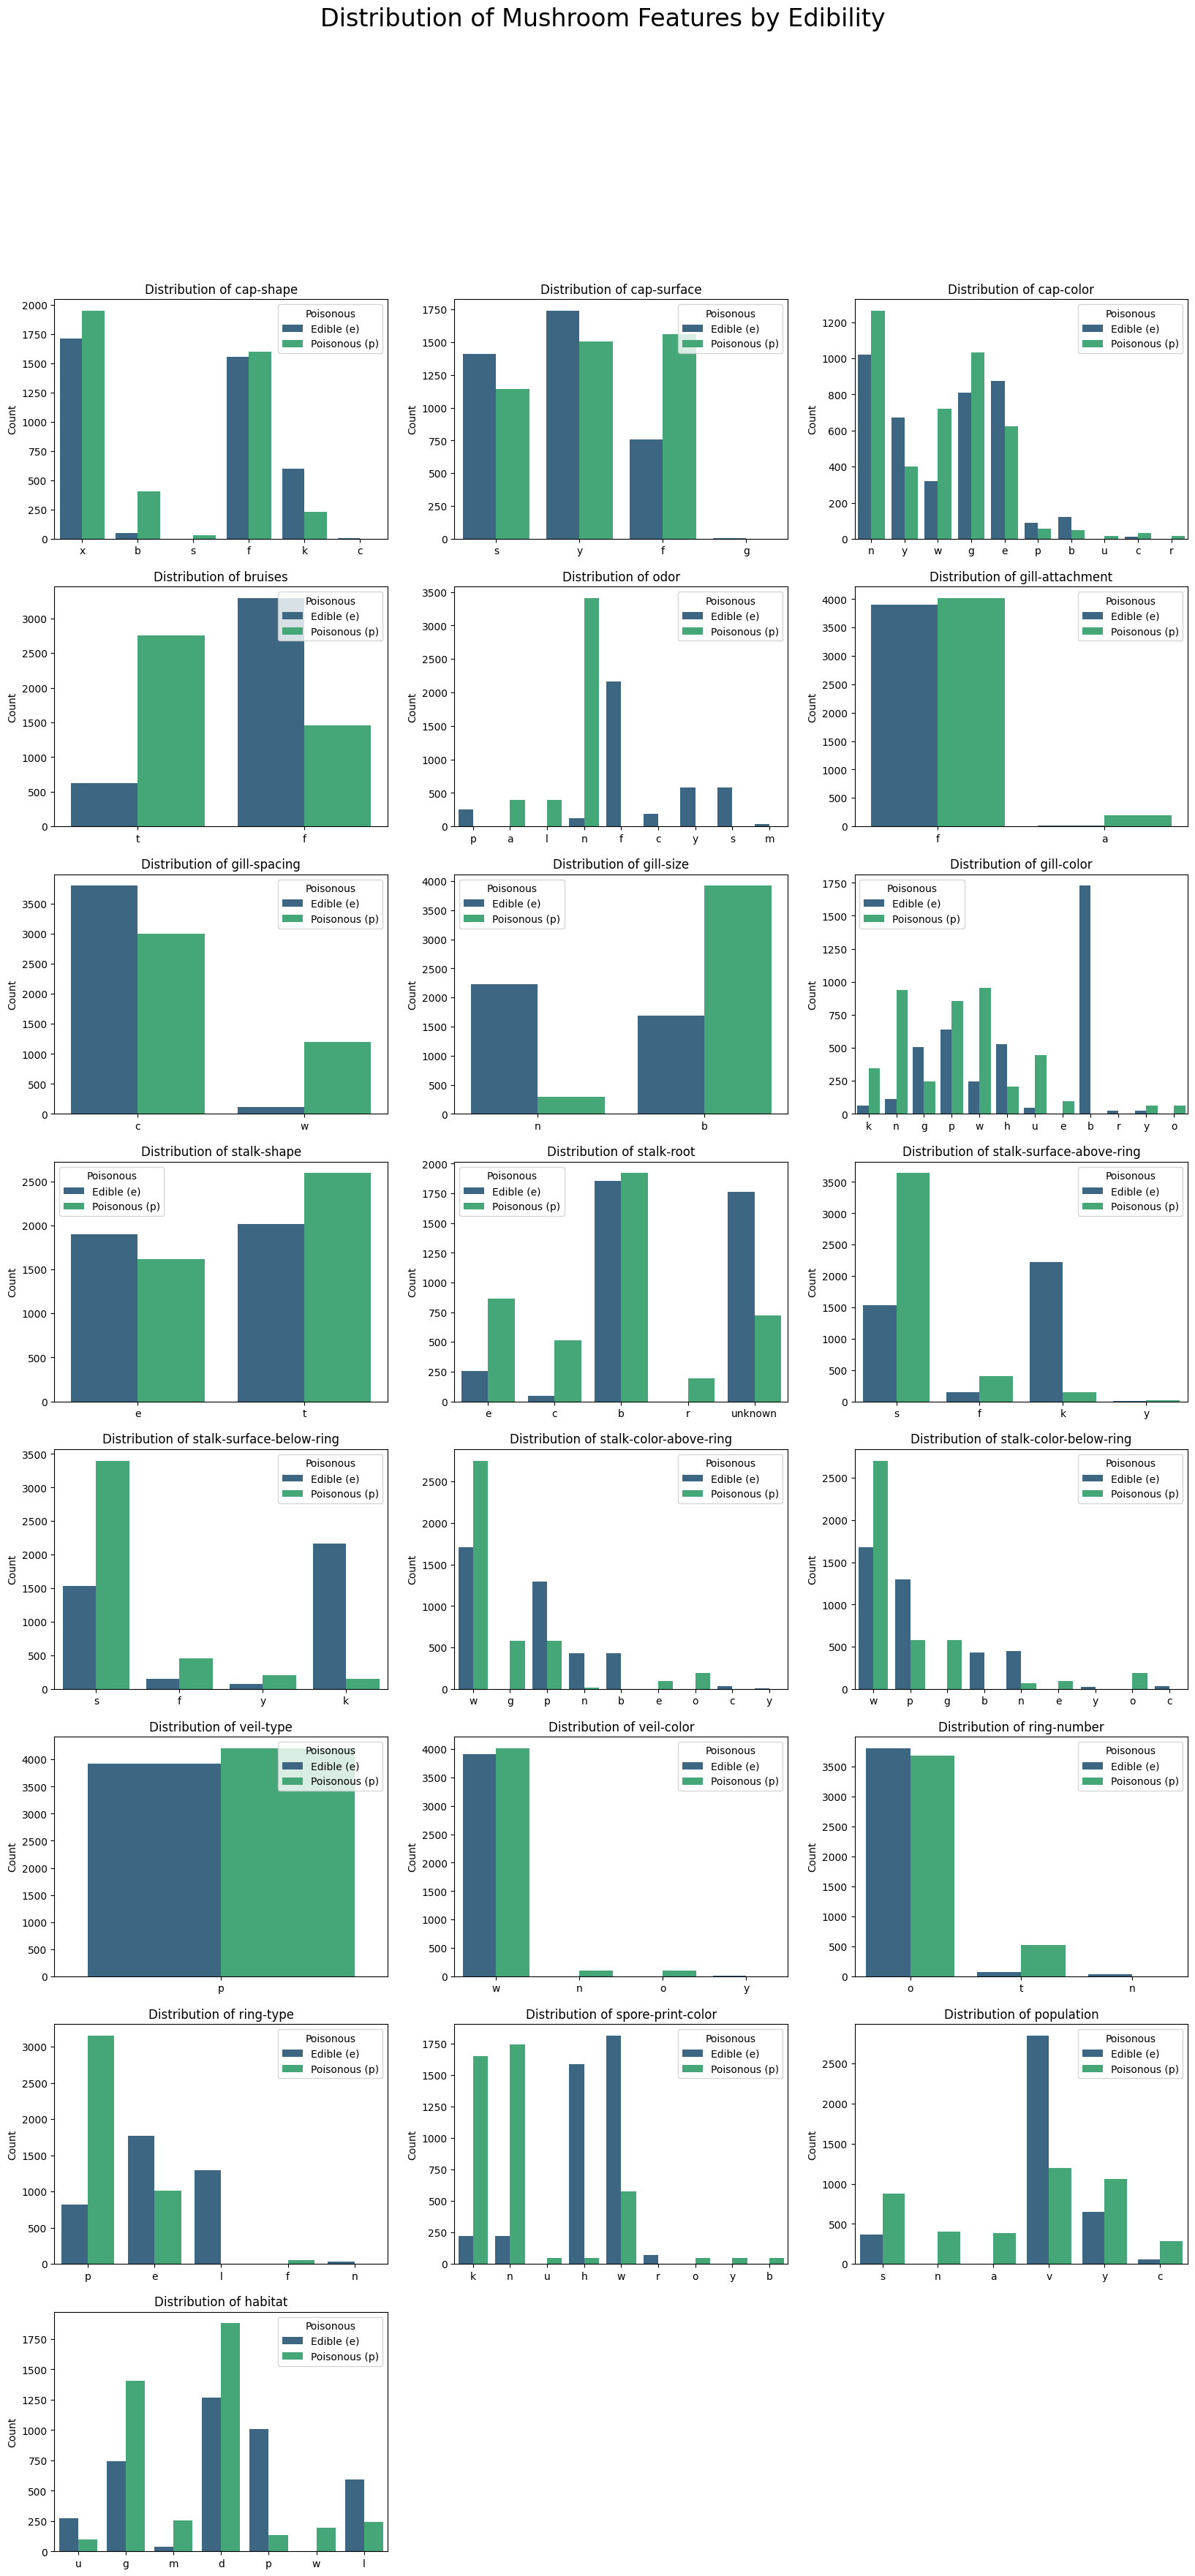

In [ ]:
# Temporary dataframe for EDA
df_eda = pd.concat([x,y],
                   axis = 1
                   )

# Specify how many columns we want for the plots
cols = x.columns
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)


fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize = (20, n_rows * 5)
                         )
fig.suptitle('Distribution of Mushroom Features by Edibility',
             fontsize = 24
             )

# For loop that iterates through each feature to generate a grid of subplots
for i, col in enumerate(cols):
    ax = axes[i // n_cols, i % n_cols]
    sns.countplot(data = df_eda,
                  x = col,
                  hue = 'poisonous',
                  ax = ax,
                  palette = 'viridis'
                  )
    ax.set_title(f'Distribution of {col}',
                 fontsize = 12,
                 y = 1
                 )
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title='Poisonous',
              labels=['Edible (e)', 'Poisonous (p)']
              )

# Second for loop that deletes the empty subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

plt.show()

# Preparing the data for our model

## Why We Chose the Decision Tree Classifier

We selected the Decision Tree Classifier for this project because it fits the structure and goals of our application well.

Our application asks users to provide different mushroom characteristics, and the model evaluates those characteristics one step at a time before making a prediction. Decision trees work in the same way by checking features in sequence and following a path from the root of the tree to a final outcome. Because of this, the model aligns naturally with the way our input data is organized.

Another advantage is that decision trees are easy to understand and visualize. The model can be displayed as a diagram that clearly shows which features are being used and the order in which decisions are made. This level of transparency is important in a project where understanding the reasoning behind a prediction matters just as much as the prediction itself.

Decision trees also allow us to explain why a prediction was made. Since determining whether a mushroom is edible or poisonous can involve serious consequences, it is important to see how the model reached its conclusion. By tracing the path through the tree, both users and developers can better understand and trust the result.

The model is also well suited for categorical data. The UCI mushroom dataset is made entirely of categorical features such as cap shape, odor, and gill color. Although we use one hot encoding so the data can be processed with scikit learn, decision trees still perform very effectively with this type of feature based data.

In [ ]:
# Create the train and test sets
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42
                                                    )


In [ ]:
categorical_features = x.columns.tolist()

preprocessing = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Training

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Build the full pipeline: preprocessing + classifier
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Train the model on the training set
full_pipeline.fit(x_train, y_train.values.ravel())

print("Model trained successfully.")
print(f"Number of training samples: {x_train.shape[0]}")
print(f"Number of test samples: {x_test.shape[0]}")

Model trained successfully.
Number of training samples: 6499
Number of test samples: 1625


# Fine-tuning

## Why We Use Recall as Our Scoring Metric

When tuning this model, we optimize for recall rather than accuracy or precision.

Recall measures how many of the truly poisonous mushrooms the model correctly identifies as poisonous. In other words, it minimizes false negatives cases where the model predicts "edible" but the mushroom is actually poisonous.

In this context, a false negative is far more dangerous than a false positive:
- False negative model says edible → person eats a poisonous mushroom → potentially fatal
- False positive model says poisonous → person discards a safe mushroom → minor inconvenience

Because the cost of the two types of errors is so unequal, recall is the right metric to prioritize.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters to search over
param_grid = {
    "classifier__max_depth": [3, 5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__criterion": ["gini", "entropy"]
}

# Run grid search with recall as the scoring metric
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train.values.ravel())

print("Best parameters:", grid_search.best_params_)
print("Best recall score (cross-validated):", round(grid_search.best_score_, 4))

# Save the best model as our new pipeline
best_pipeline = grid_search.best_estimator_

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best recall score (cross-validated): nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


# Evaluation and performance

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions on the test set
y_pred = best_pipeline.predict(x_test)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Edible", "Poisonous"]))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Edible", "Poisonous"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Results and Analysis

The classification report gives us four key metrics for each class:

- **Precision**: Of all the mushrooms the model predicted as poisonous, how many actually were?
- **Recall**: Of all the truly poisonous mushrooms, how many did the model correctly catch?
- **F1-score**: The harmonic mean of precision and recall — a single balanced measure of performance.
- **Accuracy**: Overall percentage of correct predictions across both classes.

### Confusion Matrix Breakdown
- **Top-left (True Negatives)**: Correctly predicted edible
- **Top-right (False Positives)**: Predicted poisonous, actually edible
- **Bottom-left (False Negatives)**: Predicted edible, actually poisonous ← most dangerous
- **Bottom-right (True Positives)**: Correctly predicted poisonous

Since we tuned for recall, we expect the model to have very few false negatives — meaning it rarely misses a poisonous mushroom. Any false negatives observed here should be examined closely.

# Saving and deploying the model

In [ ]:
import joblib

# Save the trained pipeline to a .pkl file
joblib.dump(best_pipeline, "mushroom_model.pkl")

print("Model saved as mushroom_model.pkl")

Model saved as mushroom_model.pkl


In github repo: app.py

import streamlit as st
import joblib
import pandas as pd

# Load the saved model
model = joblib.load("mushroom_model.pkl")

st.title("🍄 Mushroom Edibility Predictor")
st.write("Select the physical characteristics of your mushroom to find out if it's safe to eat.")

# --- Feature options (from UCI dataset) ---
cap_shape = st.selectbox("Cap Shape", ["bell (b)", "conical (c)", "convex (x)", "flat (f)", "knobbed (k)", "sunken (s)"])
cap_surface = st.selectbox("Cap Surface", ["fibrous (f)", "grooves (g)", "scaly (y)", "smooth (s)"])
cap_color = st.selectbox("Cap Color", ["brown (n)", "buff (b)", "cinnamon (c)", "gray (g)", "green (r)", "pink (p)", "purple (u)", "red (e)", "white (w)", "yellow (y)"])
bruises = st.selectbox("Bruises", ["yes (t)", "no (f)"])
odor = st.selectbox("Odor", ["almond (a)", "anise (l)", "creosote (c)", "fishy (y)", "foul (f)", "musty (m)", "none (n)", "pungent (p)", "spicy (s)"])
gill_attachment = st.selectbox("Gill Attachment", ["attached (a)", "descending (d)", "free (f)", "notched (n)"])
gill_spacing = st.selectbox("Gill Spacing", ["close (c)", "crowded (w)", "distant (d)"])
gill_size = st.selectbox("Gill Size", ["broad (b)", "narrow (n)"])
gill_color = st.selectbox("Gill Color", ["black (k)", "brown (n)", "buff (b)", "chocolate (h)", "gray (g)", "green (r)", "orange (o)", "pink (p)", "purple (u)", "red (e)", "white (w)", "yellow (y)"])
stalk_shape = st.selectbox("Stalk Shape", ["enlarging (e)", "tapering (t)"])
stalk_root = st.selectbox("Stalk Root", ["bulbous (b)", "club (c)", "cup (u)", "equal (e)", "rhizomorphs (z)", "rooted (r)", "unknown"])
stalk_surface_above_ring = st.selectbox("Stalk Surface Above Ring", ["fibrous (f)", "scaly (y)", "silky (k)", "smooth (s)"])
stalk_surface_below_ring = st.selectbox("Stalk Surface Below Ring", ["fibrous (f)", "scaly (y)", "silky (k)", "smooth (s)"])
stalk_color_above_ring = st.selectbox("Stalk Color Above Ring", ["brown (n)", "buff (b)", "cinnamon (c)", "gray (g)", "orange (o)", "pink (p)", "red (e)", "white (w)", "yellow (y)"])
stalk_color_below_ring = st.selectbox("Stalk Color Below Ring", ["brown (n)", "buff (b)", "cinnamon (c)", "gray (g)", "orange (o)", "pink (p)", "red (e)", "white (w)", "yellow (y)"])
veil_color = st.selectbox("Veil Color", ["brown (n)", "orange (o)", "white (w)", "yellow (y)"])
ring_number = st.selectbox("Ring Number", ["none (n)", "one (o)", "two (t)"])
ring_type = st.selectbox("Ring Type", ["cobwebby (c)", "evanescent (e)", "flaring (f)", "large (l)", "none (n)", "pendant (p)", "sheathing (s)", "zone (z)"])
spore_print_color = st.selectbox("Spore Print Color", ["black (k)", "brown (n)", "buff (b)", "chocolate (h)", "green (r)", "orange (o)", "purple (u)", "white (w)", "yellow (y)"])
population = st.selectbox("Population", ["abundant (a)", "clustered (c)", "numerous (n)", "scattered (s)", "several (v)", "solitary (y)"])
habitat = st.selectbox("Habitat", ["grasses (g)", "leaves (l)", "meadows (m)", "paths (p)", "urban (u)", "waste (w)", "woods (d)"])

# --- Extract just the letter code from each selection ---
def extract_code(selection):
    return selection.split("(")[-1].replace(")", "").strip()

input_data = pd.DataFrame([{
    "cap-shape": extract_code(cap_shape),
    "cap-surface": extract_code(cap_surface),
    "cap-color": extract_code(cap_color),
    "bruises": extract_code(bruises),
    "odor": extract_code(odor),
    "gill-attachment": extract_code(gill_attachment),
    "gill-spacing": extract_code(gill_spacing),
    "gill-size": extract_code(gill_size),
    "gill-color": extract_code(gill_color),
    "stalk-shape": extract_code(stalk_shape),
    "stalk-root": extract_code(stalk_root),
    "stalk-surface-above-ring": extract_code(stalk_surface_above_ring),
    "stalk-surface-below-ring": extract_code(stalk_surface_below_ring),
    "stalk-color-above-ring": extract_code(stalk_color_above_ring),
    "stalk-color-below-ring": extract_code(stalk_color_below_ring),
    "veil-color": extract_code(veil_color),
    "ring-number": extract_code(ring_number),
    "ring-type": extract_code(ring_type),
    "spore-print-color": extract_code(spore_print_color),
    "population": extract_code(population),
    "habitat": extract_code(habitat),
}])

# --- Predict ---
if st.button("Predict"):
    prediction = model.predict(input_data)[0]
    if prediction == "p":
        st.error("⚠️ This mushroom is likely POISONOUS. Do not eat it.")
    else:
        st.success("✅ This mushroom is likely EDIBLE.")
    st.warning("Disclaimer: This tool is for educational purposes only. Never eat a wild mushroom based solely on this prediction.")

```
# This is formatted as code
```

